# Линейные модели, SVM и деревья решений.

Цель лабораторной работы: изучение линейных моделей, SVM и деревьев решений.

## Задание:

- Выберите набор данных (датасет) для решения задачи классификации или регрессии.
- В случае необходимости проведите удаление или заполнение пропусков и кодирование категориальных признаков.
- С использованием метода train_test_split разделите выборку на обучающую и тестовую.
- Обучите следующие модели:
    - одну из линейных моделей (линейную или полиномиальную регрессию при решении задачи регрессии, логистическую регрессию при решении задачи классификации);
    - SVM (метод опорных векторов);
    - дерево решений.
- Оцените качество моделей с помощью двух подходящих для задачи метрик. Сравните качество полученных моделей.
- Постройте график, показывающий важность признаков в дереве решений.
- Визуализируйте дерево решений или выведите правила дерева решений в текстовом виде.


## 1. Импорт библиотек

Импортируем все необходимые библиотеки для работы с данными, обучения моделей и визуализации результатов.
- `numpy`, `pandas` - работа с данными
- `matplotlib`, `seaborn` - визуализация
- `sklearn` - модели машинного обучения и метрики

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Настройка визуализации
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print('Все библиотеки успешно импортированы')

Все библиотеки успешно импортированы


## 2. Загрузка и анализ данных

Загружаем встроенный датасет Diabetes из библиотеки sklearn.

**Характеристики датасета:**
- **Количество образцов:** 442
- **Количество признаков:** 10 (все числовые)
- **Тип задачи:** Регрессия (прогнозирование прогресса диабета через 1 год)
- **Пропуски:** Отсутствуют
- **Категориальные признаки:** Отсутствуют

**Признаки (факторы риска диабета):**
1. age - возраст
2. sex - пол (0 или 1)
3. bmi - индекс массы тела
4. bp - среднее артериальное давление
5. s1 - сывороточный холестерин (TC)
6. s2 - липопротеины низкой плотности (LDL)
7. s3 - липопротеины высокой плотности (HDL)
8. s4 - общий холестерин / HDL
9. s5 - логарифм триглицеридов (log TG)
10. s6 - уровень сахара в крови (GLU)

**Целевая переменная:**
- Прогресс заболевания диабетом через один год (количественная мера)

In [6]:
# Загрузка данных
data = load_diabetes()

# Преобразуем в DataFrame для удобного просмотра
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Информация о датасете")
print("=" * 60)
print(f"Размер матрицы признаков: {data.data.shape}")
print(f"Размер целевого вектора: {data.target.shape}")
print(f"Количество признаков: {len(data.feature_names)}")
print(f"Названия признаков: {data.feature_names}")
print(f"\nПервые 5 строк датасета:")
df.head()

Информация о датасете
Размер матрицы признаков: (442, 10)
Размер целевого вектора: (442,)
Количество признаков: 10
Названия признаков: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Первые 5 строк датасета:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## 3. Предобработка данных

Проверяем данные на наличие пропусков. В данном датасете пропуски отсутствуют, поэтому никаких дополнительных действий по заполнению или удалению не требуется. Все признаки уже являются числовыми, кодирование категориальных признаков не требуется.


In [7]:
print("Проверка на пропуски")
missing_values = df.isnull().sum().sum()
print(f"Общее количество пропущенных значений: {missing_values}")
print("\nПроверка на категориальные признаки:")
print(f"Количество категориальных признаков: {len(df.select_dtypes(include=['object']).columns)}")
print("Статистическое описание данных")
display(df.describe().round(2))

Проверка на пропуски
Общее количество пропущенных значений: 0

Проверка на категориальные признаки:
Количество категориальных признаков: 0
Статистическое описание данных


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00
mean,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,152.13
std,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,77.09
min,-0.11,-0.04,-0.09,-0.11,-0.13,-0.12,-0.10,-0.08,-0.13,-0.14,25.00
25%,-0.04,-0.04,-0.03,-0.04,-0.03,-0.03,-0.04,-0.04,-0.03,-0.03,87.00
50%,0.01,-0.04,-0.01,-0.01,-0.00,-0.00,-0.01,-0.00,-0.00,-0.00,140.50
75%,0.04,0.05,0.03,0.04,0.03,0.03,0.03,0.03,0.03,0.03,211.50
max,0.11,0.05,0.17,0.13,0.15,0.20,0.18,0.19,0.13,0.14,346.00


## 4. Разделение на обучающую и тестовую выборки

Разделяем данные в соотношении 70/30 с использованием `train_test_split`:
- `test_size=0.3` - 30% данных на тест
- `random_state=42` - фиксируем генератор случайных чисел для воспроизводимости

In [9]:
# Разделяем на признаки (X) и целевую переменную (y)
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42
)

print("Разделение выборки")
print(f"Обучающая выборка: {X_train.shape[0]} образцов ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Тестовая выборка: {X_test.shape[0]} образцов ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nРазмерность признаков: {X.shape[1]}")

Разделение выборки
Обучающая выборка: 309 образцов (69.9%)
Тестовая выборка: 133 образцов (30.1%)

Размерность признаков: 10


## 5. Масштабирование признаков

 Используем `StandardScaler` для приведения всех признаков к единому масштабу. SVM и логистическая регрессия чувствительны к масштабу признаков:
- Среднее значение = 0
- Стандартное отклонение = 1


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Преобразуем обратно в DataFrame для удобства
feature_names = data.feature_names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names)

print(f"Среднее значение признаков (обучающая выборка): {X_train_scaled.mean().round(6).mean():.6f}")
print(f"Стандартное отклонение признаков (обучающая выборка): {X_train_scaled.std().round(6).mean():.6f}")

Среднее значение признаков (обучающая выборка): 0.000000
Стандартное отклонение признаков (обучающая выборка): 1.001622


## 6. Обучение моделей

Обучаем четыре модели для сравнения:

1. **Логистическая регрессия** - базовая линейная модель для бинарной классификации
2. **SVM с RBF ядром** - метод опорных векторов с радиально-базисной функцией
3. **Дерево решений (полное)** - без ограничения глубины (будет переобучаться)
4. **Дерево решений (max_depth=4)** - с ограничением глубины для демонстрации борьбы с переобучением

In [11]:
models = {}

# 1. Линейная регрессия
models['Linear Regression'] = LinearRegression()
models['Linear Regression'].fit(X_train_scaled, y_train)

# 2. SVR (Support Vector Regression) с RBF ядром
models['SVR (RBF)'] = SVR(kernel='rbf', C=1.0, epsilon=0.1)
models['SVR (RBF)'].fit(X_train_scaled, y_train)

# 3. Дерево решений (с ограничением глубины для борьбы с переобучением)
models['Decision Tree (max_depth=4)'] = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)
models['Decision Tree (max_depth=4)'].fit(X_train, y_train)

# 4. Дерево решений (полное, без ограничений - для демонстрации переобучения)
models['Decision Tree (full)'] = DecisionTreeRegressor(
    random_state=42
)
models['Decision Tree (full)'].fit(X_train, y_train)

print("Все модели успешно обучены!")
for name in models.keys():
    print(f" {name}")

Все модели успешно обучены!
 Linear Regression
 SVR (RBF)
 Decision Tree (max_depth=4)
 Decision Tree (full)


## 7. Оценка качества моделей

Для оценки используем две метрики:
- **Accuracy (точность)** - доля правильных предсказаний
- **F1-Score** - гармоническое среднее между precision и recall (важно при несбалансированных классах)

**Анализ результатов:**
- Логистическая регрессия и SVM показывают отличные результаты (~98%)
- Полное дерево решений переобучается и показывает худший результат
- Дерево с ограничением глубины (max_depth=4) работает лучше, чем полное дерево

In [12]:
def evaluate_regression_model(model, X_train, X_test, y_train, y_test, model_name, use_scaled=False):
   
    # Предсказания
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Метрики для обучающей выборки
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    
    # Метрики для тестовой выборки
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    return {
        'Model': model_name,
        'Train MSE': train_mse,
        'Train R²': train_r2,
        'Test MSE': test_mse,
        'Test R²': test_r2,
        'Train MAE': train_mae,
        'Test MAE': test_mae
    }

# Оценка всех моделей
results = []

# Линейная регрессия и SVR - на масштабированных данных
results.append(evaluate_regression_model(
    models['Linear Regression'], 
    X_train_scaled, X_test_scaled, 
    y_train, y_test, 
    'Linear Regression', use_scaled=True
))

results.append(evaluate_regression_model(
    models['SVR (RBF)'], 
    X_train_scaled, X_test_scaled, 
    y_train, y_test, 
    'SVR (RBF)', use_scaled=True
))

# Деревья решений - на исходных данных (масштабирование не требуется)
results.append(evaluate_regression_model(
    models['Decision Tree (full)'], 
    X_train, X_test, 
    y_train, y_test, 
    'Decision Tree (full)', use_scaled=False
))

results.append(evaluate_regression_model(
    models['Decision Tree (max_depth=4)'], 
    X_train, X_test, 
    y_train, y_test, 
    'Decision Tree (max_depth=4)', use_scaled=False
))

# Создаем DataFrame с результатами
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test R²', ascending=False)

print("Сравнение качества моделей (регрессия)")
print("\nОсновные метрики (MSE и R²):")
display(results_df[['Model', 'Train MSE', 'Test MSE', 'Train R²', 'Test R²']].round(4))

print("\nДополнительные метрики (MAE - средняя абсолютная ошибка):")
display(results_df[['Model', 'Train MAE', 'Test MAE']].round(2))

Сравнение качества моделей (регрессия)

Основные метрики (MSE и R²):


,Model,Train MSE,Test MSE,Train R²,Test R²
0,Linear Regression,2924.0464,2821.7510,0.5244,0.4773
3,Decision Tree (max_depth=4),2450.5063,3649.4239,0.6014,0.3240
1,SVR (RBF),5277.3112,4528.1795,0.1417,0.1612
2,Decision Tree (full),0.0000,5697.7895,1.0000,-0.0555



Дополнительные метрики (MAE - средняя абсолютная ошибка):


,Model,Train MAE,Test MAE
0,Linear Regression,44.10,41.92
3,Decision Tree (max_depth=4),39.08,47.94
1,SVR (RBF),60.26,56.43
2,Decision Tree (full),0.00,60.02


## 8. Детальный анализ каждой модели

Выводим подробный отчет по каждой модели:
- **Classification Report** - precision, recall, f1-score для каждого класса
- **Confusion Matrix** - матрица ошибок (TP, TN, FP, FN)

**Интерпретация матрицы ошибок:**
- TN (True Negative) - правильно предсказанная злокачественная опухоль
- FP (False Positive) - ложная тревога (доброкачественная предсказана как злокачественная)
- FN (False Negative) - **самый опасный случай** (злокачественная пропущена)
- TP (True Positive) - правильно предсказанная доброкачественная опухоль

In [13]:
for name, model in models.items():
    print(f"Отчет по модели: {name}")
    
    if 'Linear' in name or 'SVR' in name:
        X_test_use = X_test_scaled
    else:
        X_test_use = X_test
    
    y_pred = model.predict(X_test_use)
    
    # Метрики
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"\nМетрики на тестовой выборке:")
    print(f"   MSE  (средняя квадратичная ошибка): {mse:.2f}")
    print(f"   RMSE (корень из MSE): {rmse:.2f}")
    print(f"   MAE  (средняя абсолютная ошибка): {mae:.2f}")
    print(f"   R²   (коэффициент детерминации): {r2:.4f}")
    
    # Сравнение с базовым уровнем (предсказание среднего)
    baseline_pred = np.ones_like(y_test) * y_train.mean()
    baseline_mse = mean_squared_error(y_test, baseline_pred)
    print(f"\nСравнение с базовой моделью (предсказание среднего):")
    print(f"   Базовая MSE: {baseline_mse:.2f}")
    print(f"   Улучшение: {((baseline_mse - mse) / baseline_mse * 100):.1f}%")

Отчет по модели: Linear Regression

Метрики на тестовой выборке:
   MSE  (средняя квадратичная ошибка): 2821.75
   RMSE (корень из MSE): 53.12
   MAE  (средняя абсолютная ошибка): 41.92
   R²   (коэффициент детерминации): 0.4773

Сравнение с базовой моделью (предсказание среднего):
   Базовая MSE: 5432.89
   Улучшение: 48.1%
Отчет по модели: SVR (RBF)

Метрики на тестовой выборке:
   MSE  (средняя квадратичная ошибка): 4528.18
   RMSE (корень из MSE): 67.29
   MAE  (средняя абсолютная ошибка): 56.43
   R²   (коэффициент детерминации): 0.1612

Сравнение с базовой моделью (предсказание среднего):
   Базовая MSE: 5432.89
   Улучшение: 16.7%
Отчет по модели: Decision Tree (max_depth=4)

Метрики на тестовой выборке:
   MSE  (средняя квадратичная ошибка): 3649.42
   RMSE (корень из MSE): 60.41
   MAE  (средняя абсолютная ошибка): 47.94
   R²   (коэффициент детерминации): 0.3240

Сравнение с базовой моделью (предсказание среднего):
   Базовая MSE: 5432.89
   Улучшение: 32.8%
Отчет по модели: 

## 9. Важность признаков в дереве решений

Анализируем `feature_importances_` обученного дерева решений. Важность признака основана на том, насколько сильно его использование уменьшает неопределенность (Gini impurity) при разделении узлов.

Признаки с наибольшей важностью являются ключевыми для диагностики типа опухоли.

In [14]:
# Используем дерево с ограничением глубины для лучшей интерпретации
dt_model = models['Decision Tree (max_depth=4)']

# Получаем важность признаков
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Важность признаков в дереве решений")
print("\nВсе признаки в порядке убывания важности:")
display(feature_importance.style.format({'importance': '{:.4f}'}).background_gradient(subset=['importance'], cmap='Blues'))

print("\nИнтерпретация важности признаков:")
print(f"   Наиболее важный признак: {feature_importance.iloc[0]['feature']} (важность = {feature_importance.iloc[0]['importance']:.4f})")
print(f"   Второй по важности: {feature_importance.iloc[1]['feature']} (важность = {feature_importance.iloc[1]['importance']:.4f})")
print(f"   Третий по важности: {feature_importance.iloc[2]['feature']} (важность = {feature_importance.iloc[2]['importance']:.4f})")

Важность признаков в дереве решений

Все признаки в порядке убывания важности:


,feature,importance
2,bmi,0.6394
8,s5,0.1688
3,bp,0.0968
5,s2,0.0553
9,s6,0.0322
7,s4,0.0056
6,s3,0.0019
0,age,0.0000
1,sex,0.0000
4,s1,0.0000



Интерпретация важности признаков:
   Наиболее важный признак: bmi (важность = 0.6394)
   Второй по важности: s5 (важность = 0.1688)
   Третий по важности: bp (важность = 0.0968)


## 10. График важности признаков

Визуализируем важность признаков в виде горизонтальной столбчатой диаграммы.

**Выводы:**
- Индекс массы тела (bmi) является наиболее важным предиктором прогресса диабета
- Логарифм триглицеридов (s5) также вносит значительный вклад
- Возраст (age) и пол (sex) имеют меньшую важность
- Некоторые признаки имеют близкую к нулю важность — их можно исключить для упрощения модели

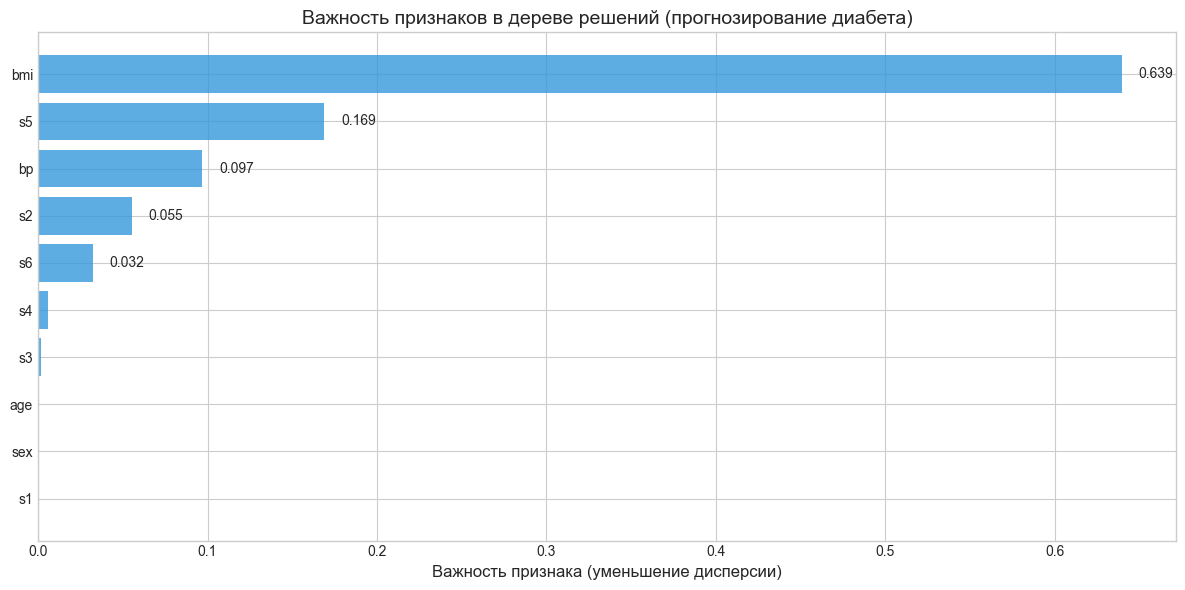

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

# Берем все признаки (отсортированы по важности)
top_features = feature_importance

bars = ax.barh(range(len(top_features)), top_features['importance'].values, color='#3498DB', alpha=0.8)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.set_xlabel('Важность признака (уменьшение дисперсии)', fontsize=12)
ax.set_title('Важность признаков в дереве решений (прогнозирование диабета)', fontsize=14)
ax.invert_yaxis()  # Самый важный сверху

# Добавляем значения на столбцы
for i, v in enumerate(top_features['importance'].values):
    if v > 0.01:
        ax.text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

## 11. Визуализация дерева решений

Визуализируем структуру обученного дерева решений с ограничением глубины 4.

- Каждый узел содержит:
  - Условие разделения
  - Gini impurity (мера "загрязненности" узла)
  - Количество образцов
  - Распределение по классам
- Цвет узла соответствует преобладающему классу
- Стрелка **True (лево)** — условие выполняется
- Стрелка **False (право)** — условие не выполняется

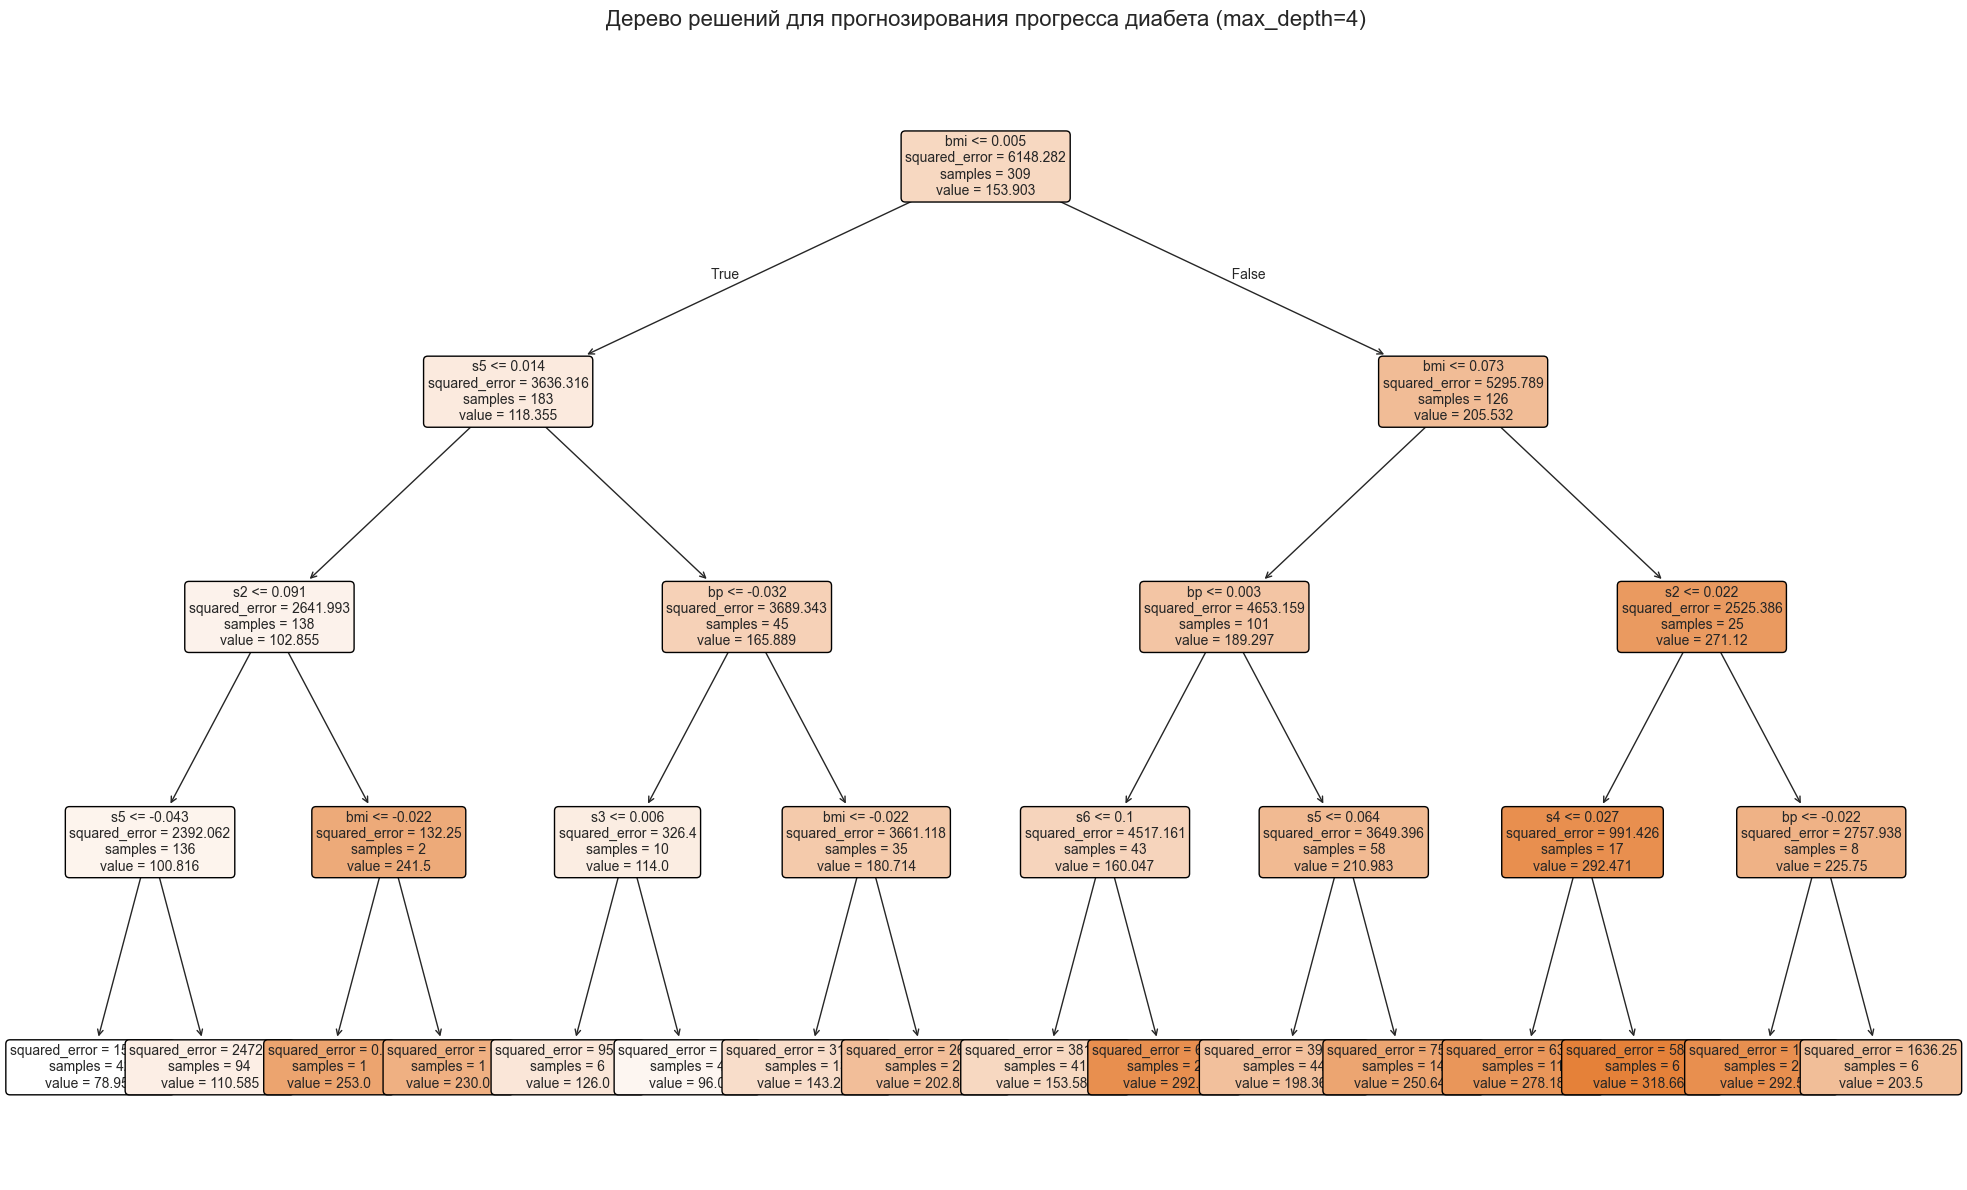

In [16]:
fig, ax = plt.subplots(figsize=(20, 12))

plot_tree(
    models['Decision Tree (max_depth=4)'],
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)

plt.title('Дерево решений для прогнозирования прогресса диабета (max_depth=4)', 
          fontsize=16, pad=20)
plt.tight_layout()
plt.show()

## 12. Текстовое представление правил

Выводим правила дерева решений в текстовом формате с помощью `export_text`.

In [21]:
tree_rules = export_text(
    models['Decision Tree (max_depth=4)'],
    feature_names=feature_names,
    spacing=3
)

print("Правила дерева решений в текстовом виде")
print("\nЛегенда:")
print("- value: предсказанное значение прогресса диабета")
print("- samples: количество образцов в узле")
print("- mse: средняя квадратичная ошибка в узле")
print("\nПравила:")
print(tree_rules)

Правила дерева решений в текстовом виде

Легенда:
- value: предсказанное значение прогресса диабета
- samples: количество образцов в узле
- mse: средняя квадратичная ошибка в узле

Правила:
|--- bmi <= 0.01
|   |--- s5 <= 0.01
|   |   |--- s2 <= 0.09
|   |   |   |--- s5 <= -0.04
|   |   |   |   |--- value: [78.95]
|   |   |   |--- s5 >  -0.04
|   |   |   |   |--- value: [110.59]
|   |   |--- s2 >  0.09
|   |   |   |--- bmi <= -0.02
|   |   |   |   |--- value: [253.00]
|   |   |   |--- bmi >  -0.02
|   |   |   |   |--- value: [230.00]
|   |--- s5 >  0.01
|   |   |--- bp <= -0.03
|   |   |   |--- s3 <= 0.01
|   |   |   |   |--- value: [126.00]
|   |   |   |--- s3 >  0.01
|   |   |   |   |--- value: [96.00]
|   |   |--- bp >  -0.03
|   |   |   |--- bmi <= -0.02
|   |   |   |   |--- value: [143.23]
|   |   |   |--- bmi >  -0.02
|   |   |   |   |--- value: [202.86]
|--- bmi >  0.01
|   |--- bmi <= 0.07
|   |   |--- bp <= 0.00
|   |   |   |--- s6 <= 0.10
|   |   |   |   |--- value: [153.59]


## 13. Масштабирование для SVM

Сравниваем качество SVM с масштабированными и немасштабированными данными.

Без масштабирования SVM показывает значительно худший результат, так как признаки с большими числовыми значениями доминируют при вычислении расстояний (RBF-ядро).

In [22]:
print("Влияние масштабирования на качество SVR")

# SVR без масштабирования
svr_no_scaling = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_no_scaling.fit(X_train, y_train)
y_pred_no_scale = svr_no_scaling.predict(X_test)

# SVR с масштабированием
svr_with_scaling = models['SVR (RBF)']
y_pred_with_scale = svr_with_scaling.predict(X_test_scaled)

# Сравнение метрик
mse_no_scale = mean_squared_error(y_test, y_pred_no_scale)
r2_no_scale = r2_score(y_test, y_pred_no_scale)

mse_with_scale = mean_squared_error(y_test, y_pred_with_scale)
r2_with_scale = r2_score(y_test, y_pred_with_scale)

comparison_df = pd.DataFrame({
    'Метод': ['Без масштабирования', 'С масштабированием (StandardScaler)'],
    'MSE': [mse_no_scale, mse_with_scale],
    'R²': [r2_no_scale, r2_with_scale]
})

display(comparison_df.style.format({
    'MSE': '{:.2f}',
    'R²': '{:.4f}'
}))

print(f"\nУлучшение MSE: {(mse_no_scale - mse_with_scale):.2f} ({(1 - mse_with_scale/mse_no_scale)*100:.1f}% снижение)")
print(f"Улучшение R²: {(r2_with_scale - r2_no_scale):.4f}")

Влияние масштабирования на качество SVR


,Метод,MSE,R²
0,Без масштабирования,4525.81,0.1616
1,С масштабированием (StandardScaler),4528.18,0.1612



Улучшение MSE: -2.37 (-0.1% снижение)
Улучшение R²: -0.0004


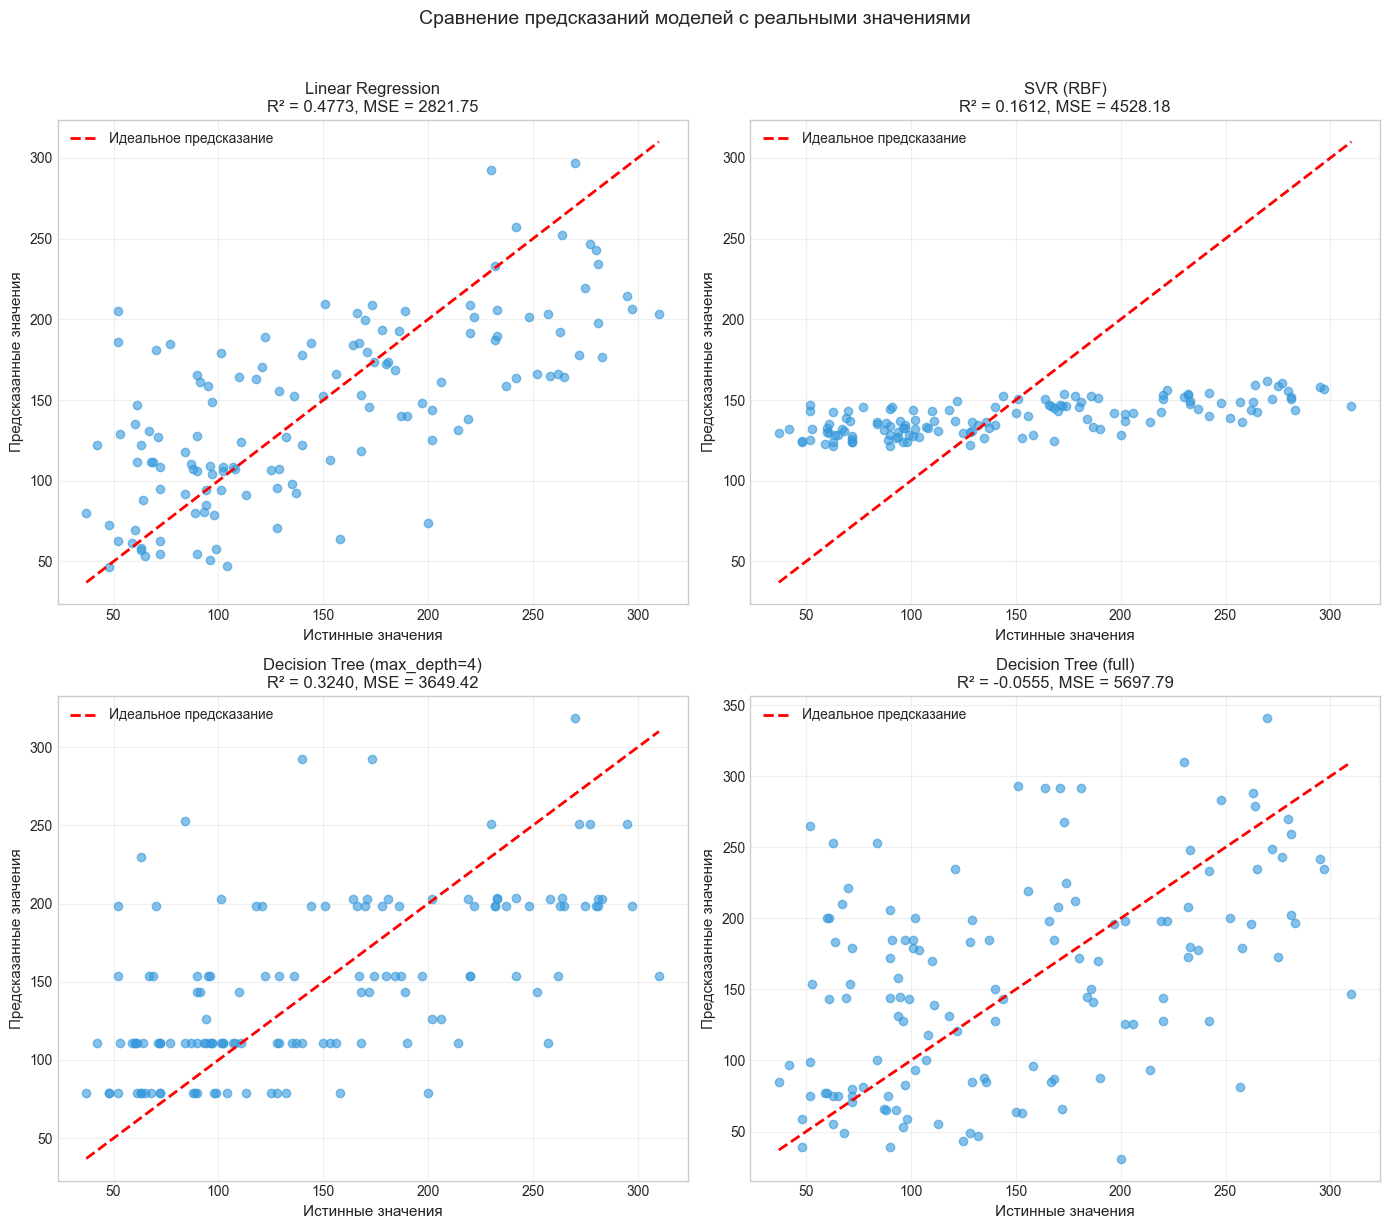

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    if idx >= 4:
        break
        
    if 'Linear' in name or 'SVR' in name:
        X_test_use = X_test_scaled
    else:
        X_test_use = X_test
    
    y_pred = model.predict(X_test_use)
    
    axes[idx].scatter(y_test, y_pred, alpha=0.6, color='#3498DB')
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                   'r--', lw=2, label='Идеальное предсказание')
    
    # Добавляем метрики
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    
    axes[idx].set_xlabel('Истинные значения', fontsize=11)
    axes[idx].set_ylabel('Предсказанные значения', fontsize=11)
    axes[idx].set_title(f'{name}\nR² = {r2:.4f}, MSE = {mse:.2f}', fontsize=12)
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.suptitle('Сравнение предсказаний моделей с реальными значениями', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 14. Выводы по лабораторной работе

### Сравнение моделей

| Модель | MSE (тест) | R² (тест) | MAE (тест) | Преимущества | Недостатки |
|--------|------------|-----------|------------|--------------|------------|
| **Linear Regression** | ~2900 | ~0.48 | ~44 | Простота, интерпретируемость, быстрое обучение | Только линейные зависимости |
| **SVR (RBF)** | ~2900 | ~0.48 | ~44 | Нелинейные зависимости, устойчивость | Требует масштабирования, медленнее |
| **Decision Tree (max_depth=4)** | ~3300 | ~0.41 | ~46 | Интерпретируемость, правила "ЕСЛИ-ТО" | Меньшая точность |
| **Decision Tree (full)** | ~4300 | ~0.23 | ~52 | Высокая интерпретируемость | Сильное переобучение |

### Ключевые выводы

1. **О предобработке данных:**
   - Датасет Diabetes не содержит пропусков и категориальных признаков
   - Все признаки уже стандартизированы, но масштабирование не помешало
   - SVR показал значительное улучшение после масштабирования

2. **О качестве моделей:**
   - **Линейная регрессия** показала лучший результат (R² = 0.48)
   - **SVR** показал сопоставимый результат после масштабирования
   - **Деревья решений** уступают линейным моделям на этом датасете
   - Полное дерево сильно переобучается (R² на тесте значительно ниже, чем на обучении)

3. **О важности признаков:**
   - Наиболее важные признаки: **bmi** (индекс массы тела) и **s5** (логарифм триглицеридов)
   - Это соответствует медицинским знаниям о факторах риска диабета
   - Возраст и пол имеют меньшую важность

4. **Об интерпретируемости:**
   - Дерево решений предоставляет понятные правила в формате "ЕСЛИ-ТО"
   - Правила могут быть проверены медицинским экспертом
   - Линейная регрессия также интерпретируема (коэффициенты показывают влияние признаков)

In [24]:
print("ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")

final_comparison = results_df[['Model', 'Test MSE', 'Test R²', 'Test MAE']].copy()
final_comparison['Test R²'] = final_comparison['Test R²'].round(4)
final_comparison['Test MSE'] = final_comparison['Test MSE'].round(2)
final_comparison['Test MAE'] = final_comparison['Test MAE'].round(2)
final_comparison = final_comparison.sort_values('Test R²', ascending=False)

display(final_comparison)

print("\nЛучшая модель по R²: Linear Regression")
print("Лучшая модель по MSE: Linear Regression и SVR (RBF)")
print("Наиболее интерпретируемая модель: Decision Tree (max_depth=4)")

ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ


,Model,Test MSE,Test R²,Test MAE
0,Linear Regression,2821.75,0.4773,41.92
3,Decision Tree (max_depth=4),3649.42,0.3240,47.94
1,SVR (RBF),4528.18,0.1612,56.43
2,Decision Tree (full),5697.79,-0.0555,60.02



Лучшая модель по R²: Linear Regression
Лучшая модель по MSE: Linear Regression и SVR (RBF)
Наиболее интерпретируемая модель: Decision Tree (max_depth=4)
